In [30]:
# Simulación de escenarios económicos para decisiones financieras
# Alejandro Cordero Bolaños
!pip install yfinance

In [31]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import time

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
def leer_banxico(ruta, nombres_columnas):
    """
    Lee un CSV exportado desde el SIE de Banxico.
    - Salta las 18 filas de informacion del encabezado
    - Renombra columnas
    - Convierte N/E a NaN
    - Convierte las fechas a tipo datetime
    - Convierte los valores a tipo float
    """
    df = pd.read_csv(
        ruta,
        encoding   = 'latin1',
        skiprows   = 18,
        header     = 0,
        na_values  = ['N/E', 'N/D', ''],
    )
    if len(df.columns) != len(nombres_columnas) + 1:
        print(f"El archivo tiene {len(df.columns)} columnas, "
              f"pero intentaste asignar {len(nombres_columnas) + 1} nombres.")
    df.columns = ['fecha'] + nombres_columnas
    df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
    # Eliminar filas donde la fecha no pudo convertirse
    df = df.dropna(subset=['fecha']).reset_index(drop=True)
    # Asegurar que los valores sean float
    for col in nombres_columnas:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

In [34]:
inflacion = leer_banxico(
    '/content/drive/MyDrive/Elem1/Inflacion.csv',
    nombres_columnas=['inflacion_mensual_pct', 'inflacion_anual_pct']
)
print('=== INFLACIÓN ===')
print(f'Período   : {inflacion.fecha.min().date()} a {inflacion.fecha.max().date()}')
print(f'Filas     : {len(inflacion):,}')
print(f'Nulos     : {inflacion.isnull().sum().to_dict()}')
inflacion.tail()

=== INFLACIÓN ===
Período   : 1969-01-01 a 2026-03-01
Filas     : 687
Nulos     : {'fecha': 0, 'inflacion_mensual_pct': 1, 'inflacion_anual_pct': 12}


,fecha,inflacion_mensual_pct,inflacion_anual_pct
682,2025-11-01,0.66,3.80
683,2025-12-01,0.28,3.69
684,2026-01-01,0.38,3.79
685,2026-02-01,0.50,4.02
686,2026-03-01,0.86,4.59


In [35]:
cambio = leer_banxico(
    '/content/drive/MyDrive/Elem1/Cambio.csv',
    nombres_columnas=['usdmxn']
)
print('=== TIPO DE CAMBIO USD/MXN ===')
print(f'Período   : {cambio.fecha.min().date()} a {cambio.fecha.max().date()}')
print(f'Filas     : {len(cambio):,}')
print(f'Nulos     : {cambio.isnull().sum().to_dict()}')
cambio.tail()

=== TIPO DE CAMBIO USD/MXN ===
Período   : 1954-04-19 a 2026-04-10
Filas     : 18,278
Nulos     : {'fecha': 0, 'usdmxn': 0}


,fecha,usdmxn
18273,2026-04-06,17.7932
18274,2026-04-07,17.7580
18275,2026-04-08,17.4157
18276,2026-04-09,17.3593
18277,2026-04-10,17.3033


In [36]:
interes = leer_banxico(
    '/content/drive/MyDrive/Elem1/Interes.csv',
    nombres_columnas=['tasa_objetivo_pct', 'tiie_28_pct']
)
print('=== TASAS DE INTERÉS ===')
print(f'Período   : {interes.fecha.min().date()} a {interes.fecha.max().date()}')
print(f'Filas     : {len(interes):,}')
print(f'Nulos     : {interes.isnull().sum().to_dict()}')
interes.tail()

=== TASAS DE INTERÉS ===
Período   : 1995-03-23 a 2026-04-13
Filas     : 9,789
Nulos     : {'fecha': 0, 'tasa_objetivo_pct': 3226, 'tiie_28_pct': 2181}


,fecha,tasa_objetivo_pct,tiie_28_pct
9784,2026-04-09,6.75,7.0071
9785,2026-04-10,6.75,6.9971
9786,2026-04-11,6.75,NaN
9787,2026-04-12,6.75,NaN
9788,2026-04-13,6.75,6.9971


In [37]:
EMISORAS = {
    'AC.MX': {'nombre': 'Arca Continental', 'sector': 'Consumo'},
    'ALSEA.MX': {'nombre': 'Alsea', 'sector': 'Consumo'},
    'AMXL.MX': {'nombre': 'América Móvil', 'sector': 'Telecomunicaciones'},
    'ASURB.MX': {'nombre': 'ASUR (Aeropuertos Sureste)', 'sector': 'Industrial'},
    'BBAJIO.MX': {'nombre': 'BanBajío', 'sector': 'Financiero'},
    'BIMBOA.MX': {'nombre': 'Bimbo', 'sector': 'Consumo'},
    'BOLSAA.MX': {'nombre': 'Bolsa Mexicana de Valores', 'sector': 'Financiero'},
    'CEMEXCPO.MX': {'nombre': 'CEMEX', 'sector': 'Materiales'},
    'CHDRAUIB.MX': {'nombre': 'Chedraui', 'sector': 'Consumo'},
    'FEMSAUBD.MX': {'nombre': 'FEMSA', 'sector': 'Consumo'},
    'GAPB.MX': {'nombre': 'GAP (Aeropuertos Pacífico)', 'sector': 'Industrial'},
    'GCARSOA1.MX': {'nombre': 'Grupo Carso', 'sector': 'Industrial'},
    'GCC.MX': {'nombre': 'GCC (Cementos)', 'sector': 'Materiales'},
    'GENTERA.MX': {'nombre': 'Gentera', 'sector': 'Financiero'},
    'GFINBURO.MX': {'nombre': 'Grupo Financiero Inbursa', 'sector': 'Financiero'},
    'GFNORTEO.MX': {'nombre': 'Grupo Financiero Banorte', 'sector': 'Financiero'},
    'GMEXICOB.MX': {'nombre': 'Grupo México', 'sector': 'Materiales'},
    'GRUMAB.MX': {'nombre': 'Gruma', 'sector': 'Consumo'},
    'KIMBERA.MX': {'nombre': 'Kimberly-Clark México', 'sector': 'Consumo'},
    'KOFL.MX': {'nombre': 'Coca-Cola FEMSA', 'sector': 'Consumo'},
    'LABB.MX': {'nombre': 'Genomma Lab', 'sector': 'Salud'},
    'LIVEPOLC-1.MX': {'nombre': 'El Puerto de Liverpool', 'sector': 'Consumo'},
    'MEGACPO.MX': {'nombre': 'Megacable', 'sector': 'Telecomunicaciones'},
    'OMAB.MX': {'nombre': 'OMA (Aeropuertos Norte)', 'sector': 'Industrial'},
    'ORBIA.MX': {'nombre': 'Orbia Advance Corp', 'sector': 'Materiales'},
    'PE&OLES.MX': {'nombre': 'Industrias Peñoles', 'sector': 'Materiales'},
    'PINFRA.MX': {'nombre': 'Pinfra', 'sector': 'Industrial'},
    'Q.MX': {'nombre': 'Qualitas', 'sector': 'Financiero'},
    'RA.MX': {'nombre': 'Regional (Banregio)', 'sector': 'Financiero'},
    'SITESB-1.MX': {'nombre': 'Sites Latinoamérica', 'sector': 'Telecomunicaciones'},
    'TLEVISACPO.MX': {'nombre': 'Televisa', 'sector': 'Telecomunicaciones'},
    'TRAXIONA.MX': {'nombre': 'Grupo Traxión', 'sector': 'Industrial'},
    'VESTA.MX': {'nombre': 'Vesta', 'sector': 'Bienes Raíces'},
    'VOLARA.MX': {'nombre': 'Volaris', 'sector': 'Industrial'},
    'WALMEX.MX': {'nombre': 'Walmart México', 'sector': 'Consumo'},
}

In [38]:
registros = []
emisoras_sin_datos = []

for ticker, info in EMISORAS.items():
    nombre = info['nombre']
    sector = info['sector']
    time.sleep(0.5)
    try:
        df = yf.download(
            ticker,
            start             = '2000-01-01',
            auto_adjust       = True,
            progress          = False,
            multi_level_index = False,
        )

        if len(df) > 100:
            df = df.reset_index()
            # Normalizar nombres de columnas (Date -> date, Close -> close, etc.)
            df.columns = [c.lower().replace(' ', '_') for c in df.columns]

            df['ticker']  = ticker
            df['empresa'] = nombre
            df['sector']  = sector

            registros.append(df)
            print(f'  ✅ {nombre:<35} | {sector:<20} | {len(df):>6,} filas')
        else:
            emisoras_sin_datos.append(ticker)
            print(f'  ⚠️  {nombre:<35} sin datos suficientes')

    except Exception as e:
        emisoras_sin_datos.append(ticker)
        print(f'  ❌ {nombre:<35} error: {e}')

# Concatenar todos los DataFrames en uno solo
if registros:
    acciones = pd.concat(registros, ignore_index=True)
    print(f'\n✅ Descarga completada')
    print(f'   Emisoras con datos : {len(registros)}')
    print(f'   Emisoras sin datos : {len(emisoras_sin_datos)}')
    print(f'   Total filas        : {len(acciones):,}')
else:
    print("\n❌ No se descargaron datos.")
acciones.info()

  ✅ Arca Continental                    | Consumo              |  5,916 filas
  ✅ Alsea                               | Consumo              |  6,657 filas


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMXL.MX']: YFTzMissingError('possibly delisted; no timezone found')


  ⚠️  América Móvil                       sin datos suficientes
  ✅ ASUR (Aeropuertos Sureste)          | Industrial           |  6,471 filas


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BBAJIO.MX']: YFTzMissingError('possibly delisted; no timezone found')


  ⚠️  BanBajío                            sin datos suficientes
  ✅ Bimbo                               | Consumo              |  6,668 filas
  ✅ Bolsa Mexicana de Valores           | Financiero           |  4,477 filas
  ✅ CEMEX                               | Materiales           |  6,668 filas
  ✅ Chedraui                            | Consumo              |  4,004 filas
  ✅ FEMSA                               | Consumo              |  6,668 filas
  ✅ GAP (Aeropuertos Pacífico)          | Industrial           |  5,063 filas
  ✅ Grupo Carso                         | Industrial           |  6,618 filas
  ✅ GCC (Cementos)                      | Materiales           |  6,013 filas
  ✅ Gentera                             | Financiero           |  3,837 filas
  ✅ Grupo Financiero Inbursa            | Financiero           |  6,668 filas
  ✅ Grupo Financiero Banorte            | Financiero           |  6,668 filas
  ✅ Grupo México                        | Materiales           |  6,668 filas


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['KOFL.MX']: YFTzMissingError('possibly delisted; no timezone found')


  ⚠️  Coca-Cola FEMSA                     sin datos suficientes
  ✅ Genomma Lab                         | Salud                |  4,474 filas
  ✅ El Puerto de Liverpool              | Consumo              |  6,665 filas
  ✅ Megacable                           | Telecomunicaciones   |  4,626 filas
  ✅ OMA (Aeropuertos Norte)             | Industrial           |  4,865 filas
  ✅ Orbia Advance Corp                  | Materiales           |  6,668 filas
  ✅ Industrias Peñoles                  | Materiales           |  6,666 filas
  ✅ Pinfra                              | Industrial           |  6,668 filas
  ✅ Qualitas                            | Financiero           |  2,701 filas
  ✅ Regional (Banregio)                 | Financiero           |  3,701 filas


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SITESB-1.MX']: YFTzMissingError('possibly delisted; no timezone found')


  ⚠️  Sites Latinoamérica                 sin datos suficientes
  ✅ Televisa                            | Telecomunicaciones   |  6,612 filas
  ✅ Grupo Traxión                       | Industrial           |  2,144 filas
  ✅ Vesta                               | Bienes Raíces        |  3,447 filas
  ✅ Volaris                             | Industrial           |  3,147 filas
  ✅ Walmart México                      | Consumo              |  5,886 filas

✅ Descarga completada
   Emisoras con datos : 31
   Emisoras sin datos : 4
   Total filas        : 170,651
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170651 entries, 0 to 170650
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     170651 non-null  datetime64[ns]
 1   close    170651 non-null  float64       
 2   high     170651 non-null  float64       
 3   low      170651 non-null  float64       
 4   open     170651 non-null  float64       
 5   v

In [39]:
# Asegurarnos de que 'date' sea formato fecha
acciones['date'] = pd.to_datetime(acciones['date'], utc=True).dt.tz_localize(None)

# Sacar el promedio del precio de cierre y volumen de TODO el mercado por mes
df_mercado = acciones.groupby('date')[['close', 'volume']].mean().reset_index()
df_mercado.set_index('date', inplace=True)
df_mercado_mensual = df_mercado.resample('ME').mean()
df_mercado_mensual.rename(columns={'close': 'bmv_close_promedio', 'volume': 'bmv_volumen_promedio'}, inplace=True)

# Preparar los datos de Banxico (Convertir a índices de fecha y agrupar por mes)
inflacion.set_index('fecha', inplace=True)
inflacion_mensual = inflacion.resample('ME').mean()

cambio.set_index('fecha', inplace=True)
cambio_mensual = cambio.resample('ME').mean()

interes.set_index('fecha', inplace=True)
interes_mensual = interes.resample('ME').mean()

In [40]:
# Unir todas las tablas usando la fecha (el índice) como puente
df_completo = inflacion_mensual.join([cambio_mensual, interes_mensual, df_mercado_mensual], how='inner')

# Filtrar para analizar desde el año 2008 en adelante (Crisis financiera hasta hoy)
# A partir de 2008 porque la tasa objetivo de Banxico tiene datos más consistentes desde entonces
df_completo = df_completo[df_completo.index >= '2008-01-01']

# Eliminar filas que hayan quedado vacías en el cruce
df_completo = df_completo.dropna()

print(f"✅ Tabla maestra creada con {len(df_completo)} meses de historia.")
display(df_completo.head())

✅ Tabla maestra creada con 219 meses de historia.


,inflacion_mensual_pct,inflacion_anual_pct,usdmxn,tasa_objetivo_pct,tiie_28_pct,bmv_close_promedio,bmv_volumen_promedio
2008-01-31,0.46,3.70,10.910014,7.5,7.925986,27.163936,4.587788e+06
2008-02-29,0.30,3.72,10.766530,7.5,7.928320,28.425569,4.147805e+06
2008-03-31,0.72,4.25,10.731311,7.5,7.931206,29.210239,4.486795e+06
2008-04-30,0.23,4.55,10.515350,7.5,7.935523,31.469367,4.392489e+06
2008-05-31,-0.11,4.95,10.435152,7.5,7.932700,30.939404,3.797848e+06


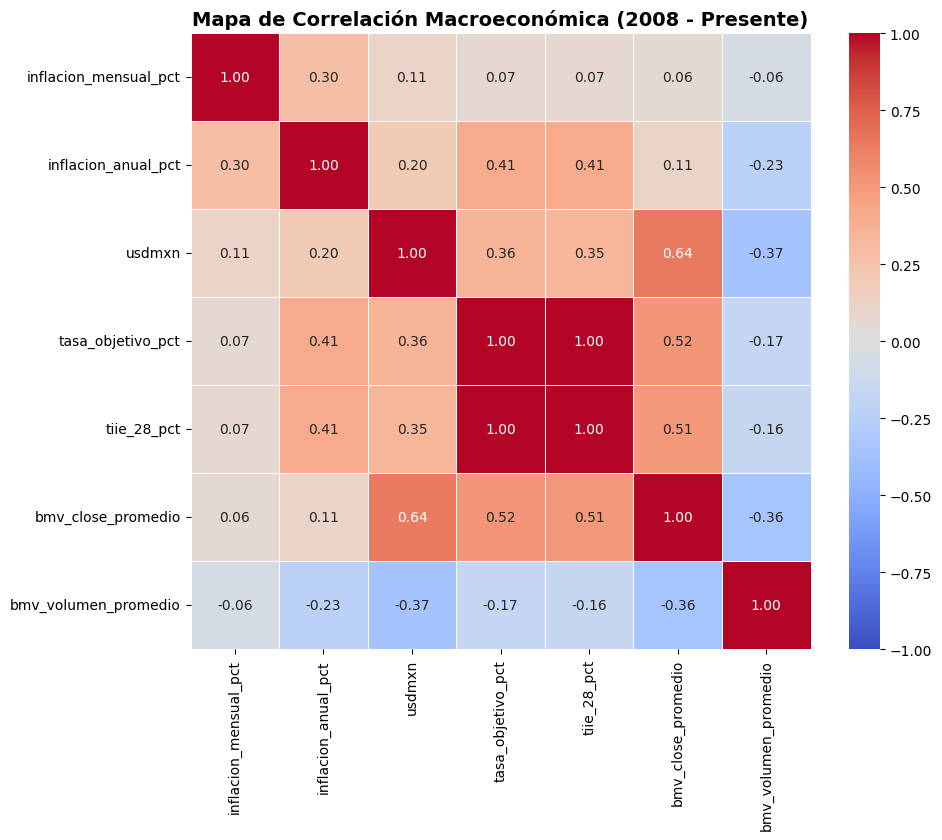

In [41]:
#===============================================================================
plt.figure(figsize=(10, 8))
# Matriz de correlación
correlacion = df_completo.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Correlación Macroeconómica (2008 - Presente)', fontsize=14, fontweight='bold')
plt.show()

In [42]:
# Grafica Inflación vs Tasa de Interés
fig1 = px.line(df_completo, x=df_completo.index,
               y=['inflacion_anual_pct', 'tasa_objetivo_pct'],
               title='Evolución: Inflación vs Tasa de Interés Objetivo',
               labels={'value': 'Porcentaje (%)', 'index': 'Fecha', 'variable': 'Indicador'},
               color_discrete_map={'inflacion_anual_pct': 'red', 'tasa_objetivo_pct': 'blue'})
fig1.update_layout(template='plotly_white', hovermode='x unified', legend_title_text='Indicadores')
fig1.show()

In [43]:
# Grafica del precio promedio de las acciones por sector
acciones_sector = acciones.groupby(['sector', 'date'])['close'].mean().reset_index()
fig2 = px.line(acciones_sector, x='date', y='close', color='sector',
               title='Precio Promedio de Cierre por Sector Económico en la BMV',
               labels={'close': 'Precio Promedio de Acción (MXN)', 'date': 'Fecha', 'sector': 'Sector Económico'})
fig2.update_layout(template='plotly_white', hovermode='x unified')
fig2.show()